In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "font.size": 12,
    })
import corner

from bilby.gw.conversion import lambda_1_lambda_2_to_lambda_tilde, lambda_1_lambda_2_to_delta_lambda_tilde, lambda_tilde_delta_lambda_tilde_to_lambda_1_lambda_2

In [2]:
narrow_df = pd.read_csv("../../events/gw/gw_params_narrow.dat", sep=" ")
kn_params = pd.read_csv("../../events/kilonova/kn_params_narrow.dat", sep=" ")
detection_df = pd.read_csv("../../events/detection/detection_output/narrow_ETL_CE.dat", sep=" ")
events = pd.read_csv("events.dat", sep=" ")

In [3]:
n_coll = np.sum(events["prompt_collapse"] ==1 )
n_tot = events.shape[0]
pop_coll_share = np.sum(narrow_df["prompt_collapse"]==1)/narrow_df.shape[0]

print(f"Prompt collapse: {n_coll}/{n_tot}, {n_coll/n_tot:.3f}, ", pop_coll_share)

Prompt collapse: 9/568, 0.016,  0.09623246050160203


In [4]:
7 / np.sum(narrow_df["prompt_collapse"]==1)  * 1e4

np.float64(8.036739380022963)

In [5]:
(637 - 7) / np.sum(narrow_df["prompt_collapse"]>=1) * 1e4

np.float64(69.60556844547564)

In [6]:
log10_mej_wind = events["log10_mej_wind"]
zeta = 10**(events["log10_mej_wind"] - events["log10_mdisk"])

print("wind quantile: ", np.quantile(log10_mej_wind, 0.05))
print("zeta quantile: ", np.quantile(zeta, 0.05))

wind quantile:  -1.4524872454214843
zeta quantile:  0.21242305354292035


In [7]:
print("SNR min max: ", np.min(events["snr"]), np.max(events["snr"]))

SNR min max:  24.096 286.207


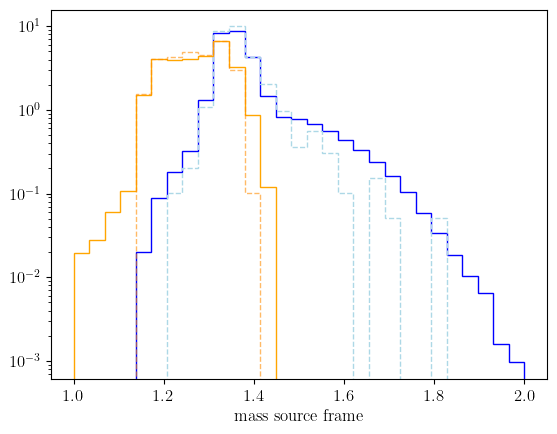

In [8]:
bins = np.linspace(1, 2, 30)

plt.hist(narrow_df["mass_1_source"], bins=bins, density=True, histtype="step", color="blue")
plt.hist(events.loc[:, "mass_1_source"], bins=bins, density=True, histtype="step", color="lightblue", linestyle="dashed")

plt.hist(narrow_df["mass_2_source"], bins=bins, density=True, color="orange", histtype="step")
plt.hist(events.loc[:, "mass_2_source"], bins=bins, density=True, histtype="step", alpha=0.6, color="darkorange", linestyle="dashed")

plt.yscale("log")
plt.xlabel("mass source frame")
plt.show()

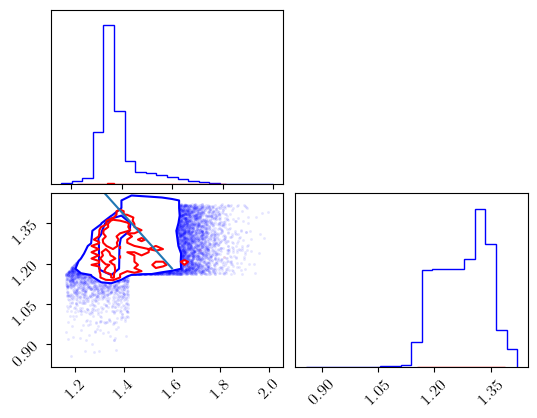

In [9]:
fig, ax = plt.subplots(2,2)

corner.corner(np.array([narrow_df["mass_1_source"], narrow_df["mass_2_source"]]).T,
                       color="blue", fig=fig, plot_density=False, levels=[0.68, 0.95])

corner.corner(np.array([events["mass_1_source"], events["mass_2_source"]]).T,
                       color="red", fig=fig, plot_density=False, levels=[0.68, 0.95])


ax[1,0].plot(np.linspace(1.2, 1.6, 10), 1.3*2.14-np.linspace(1.2, 1.6, 10))
fig.show()

(array([0.04281203, 0.05257938, 0.05184911, 0.04650902, 0.04130585,
        0.03582883, 0.03039745, 0.09625861, 3.58986634, 0.14363482]),
 array([-2.85193582, -2.60986611, -2.3677964 , -2.12572669, -1.88365698,
        -1.64158727, -1.39951756, -1.15744785, -0.91537814, -0.67330844,
        -0.43123873]),
 [<matplotlib.patches.Polygon at 0x7f47344db850>])

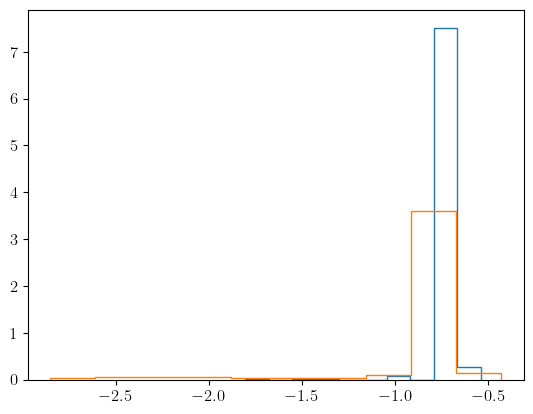

In [10]:
plt.hist(events["log10_mdisk"], histtype="step", density=True)
plt.hist(kn_params["log10_mdisk"], histtype="step", density=True)

(array([9.83327679e-03, 1.38976979e-02, 2.26820918e-02, 3.74975622e-02,
        6.85707168e-02, 1.74507885e-01, 2.17118752e-01, 2.24329821e-01,
        2.07809916e-01, 1.47236931e-01, 1.80932293e-02, 5.50663500e-03,
        6.81773858e-03, 8.65328358e-03, 1.24554839e-02, 2.16332089e-02,
        3.76286725e-02, 6.84396065e-02, 1.68214588e-01, 2.27869801e+00,
        6.81668969e+00, 6.32738584e-01, 3.06142684e-01, 1.96665536e-01,
        1.13148238e-01, 3.51375757e-02, 1.70443464e-03, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00]),
 array([-4.      , -3.915625, -3.83125 , -3.746875, -3.6625  , -3.578125,
        -3.49375 , -3.409375, -3.325   , -3.240625, -3.15625 , -3.071875,
        -2.9875  , -2.903125, -2.81875 , -2.734375, -2.65    , -2.565625,
        -2.48125 , -2.396875, -2.3125  , -2.228125, -2.14375 , -2.059375,
        -1.975   , -1.890625, -1.80625 , -1.721875, -1.6375  , -1.553125,
        -1.46875 , -1.384375, -1.3     ]),
 [<matplo

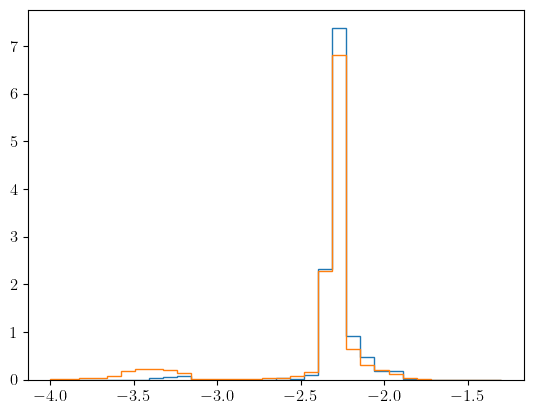

In [11]:
bins= np.linspace(-4, -1.3, 33)

plt.hist(events["log10_mej_dyn"], histtype="step", density=True, bins=bins)
plt.hist(kn_params["log10_mej_dyn"], histtype="step", density=True, bins=bins)

(array([4.69294362e-03, 4.05801595e-02, 1.55143195e-01, 3.92550931e-01,
        7.15259819e-01, 1.06419398e+00, 2.58056688e+00, 4.91047536e+00,
        6.61870684e+00, 8.50361384e+00]),
 array([0.5997643 , 0.63978706, 0.67980982, 0.71983258, 0.75985534,
        0.79987809, 0.83990085, 0.87992361, 0.91994637, 0.95996913,
        0.99999189]),
 [<matplotlib.patches.Polygon at 0x7f473424ab90>])

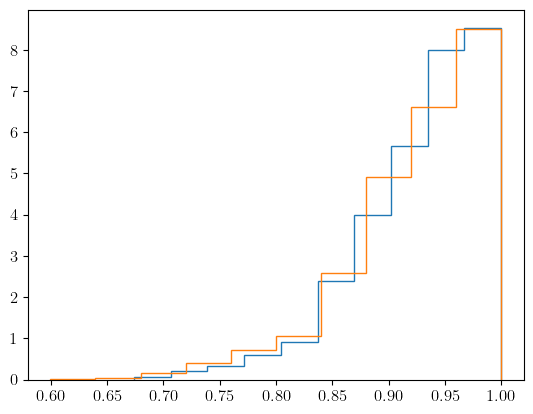

In [12]:
plt.hist(events["mass_2_source"] / events["mass_1_source"], density=True, histtype="step")
plt.hist(narrow_df["mass_2"] / narrow_df["mass_1"], density=True, histtype="step")

(array([2.15445807e-04, 2.15445807e-04, 1.07722904e-03, 2.58534969e-03,
        9.04872390e-03, 2.45608220e-02, 5.55850182e-02, 1.03413987e-01,
        1.92823997e-01, 1.09123301e+00, 2.87404707e+00, 3.20389460e+00,
        3.27499171e+00, 3.34867418e+00, 2.67001989e+00, 8.96685449e-01,
        6.04540935e-01, 4.35415976e-01, 2.99254226e-01, 1.96055684e-01,
        1.14617169e-01, 5.60159098e-02, 2.95160756e-02, 1.01259529e-02,
        3.23168711e-03, 1.72356646e-03, 2.15445807e-04, 2.15445807e-04,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00]),
 array([2.        , 2.05128205, 2.1025641 , 2.15384615, 2.20512821,
        2.25641026, 2.30769231, 2.35897436, 2.41025641, 2.46153846,
        2.51282051, 2.56410256, 2.61538462, 2.66666667, 2.71794872,
        2.76923077, 2.82051282, 2.87179487, 2.92307692, 2.97435897,
        3.02564103, 3.

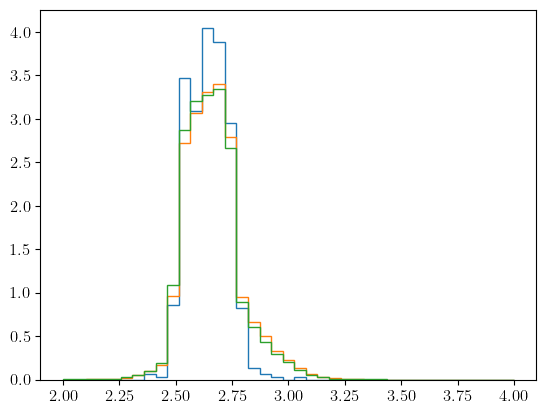

In [13]:
bins = np.linspace(2, 4, 40)

plt.hist(events["mass_2_source"] + events["mass_1_source"], density=True, histtype="step", bins=bins)
plt.hist(narrow_df.loc[detection_df["gw_detected"]. astype(bool), "mass_2_source"] + narrow_df.loc[detection_df["gw_detected"]. astype(bool), "mass_1_source"], density=True, histtype="step", bins=bins)

plt.hist(narrow_df["mass_2_source"] + narrow_df["mass_1_source"], density=True, histtype="step", bins=bins)


In [14]:
interesting_events = np.where( (2.5 < narrow_df["mass_1_source"] + narrow_df["mass_2_source"])  & ( narrow_df["mass_2_source"] + narrow_df["mass_1_source"] < 2.75) & ~detection_df["kn_visible"].astype(bool) & detection_df["gw_detected"])[0]

uninteresting_events = np.where( (2.5 < narrow_df["mass_1_source"] + narrow_df["mass_2_source"])  & ( narrow_df["mass_2_source"] + narrow_df["mass_1_source"] < 2.75) & detection_df["kn_visible"].astype(bool) & detection_df["gw_detected"])[0]

(array([0.60303982, 0.25844564, 0.77533691, 2.15371365, 3.53209038,
        3.79053602, 5.59965548, 8.27026041, 8.70100314, 8.61485459]),
 array([0.76335851, 0.78699976, 0.81064102, 0.83428228, 0.85792353,
        0.88156479, 0.90520605, 0.9288473 , 0.95248856, 0.97612982,
        0.99977107]),
 [<matplotlib.patches.Polygon at 0x7f4734159810>])

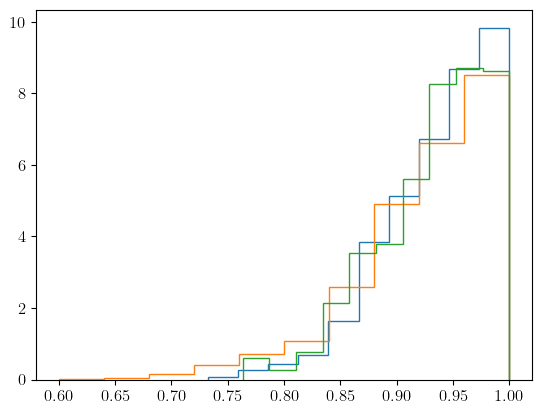

In [15]:
plt.hist(narrow_df.loc[interesting_events, "mass_2_source"] / narrow_df.loc[interesting_events, "mass_1_source"], histtype="step", density=True)

plt.hist(narrow_df["mass_2_source"] / narrow_df["mass_1_source"], density=True, histtype="step")

plt.hist(narrow_df.loc[uninteresting_events, "mass_2_source"] / narrow_df.loc[uninteresting_events, "mass_1_source"], histtype="step", density=True)


(0.0, 4000.0)

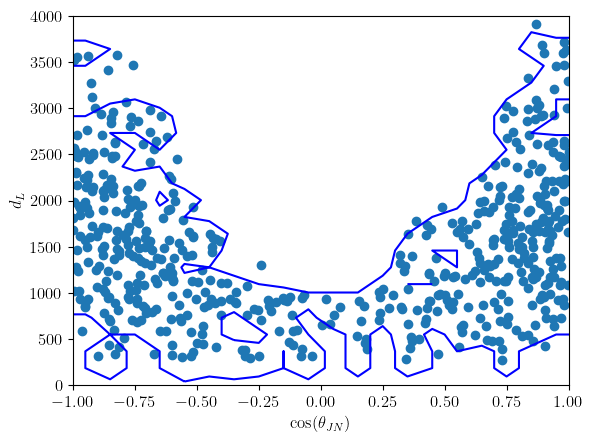

In [16]:
plt.scatter(np.cos(events["theta_jn"]), events["luminosity_distance"])
plt.ylabel("$d_L$")
plt.xlabel("$\\cos(\\theta_{JN})$")

corner.hist2d(np.cos(events["theta_jn"]).to_numpy(), events["luminosity_distance"].to_numpy(), plot_datapoints=False, no_fill_contours=True, color="blue", plot_density=False, levels=[0.95])

# u = np.linspace(-1, 1, 100)
# plt.plot(u, 600+4000 * u**4)

plt.xlim((-1, 1))
plt.ylim((0, 4000))


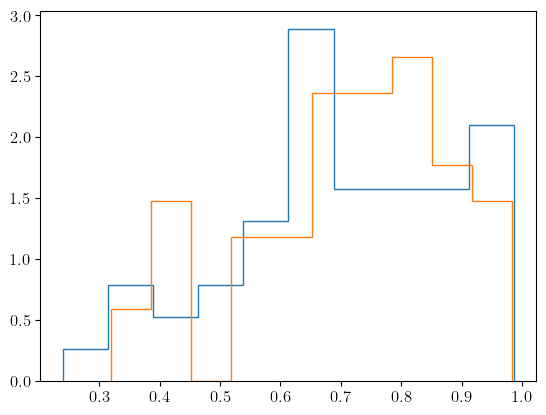

In [25]:
mask1 = events["luminosity_distance"]<1000
mask2 = (events["luminosity_distance"]<1200) & (events["luminosity_distance"]>1000)
mask3 = (events["luminosity_distance"]<1400) & (events["luminosity_distance"]>1200)
mask4 = (events["luminosity_distance"]<1600) & (events["luminosity_distance"]>1400)


#plt.hist(np.abs(np.cos(events["theta_jn"]))[mask1], histtype="step", density=True)
#plt.hist(np.abs(np.cos(events["theta_jn"]))[mask2], histtype="step", density=True)
plt.hist(np.abs(np.cos(events["theta_jn"]))[mask3], histtype="step", density=True)
plt.hist(np.abs(np.cos(events["theta_jn"]))[mask4], histtype="step", density=True)


u = np.linspace(-1, 1, 100)

#alpha=4
#plt.plot(u, (alpha+1)/2*u**(alpha))
#a = 1.5
#plt.plot(u, 1/ (1+ (np.sinh(2*a)/(2*a))) *np.cosh(a*u)**2)

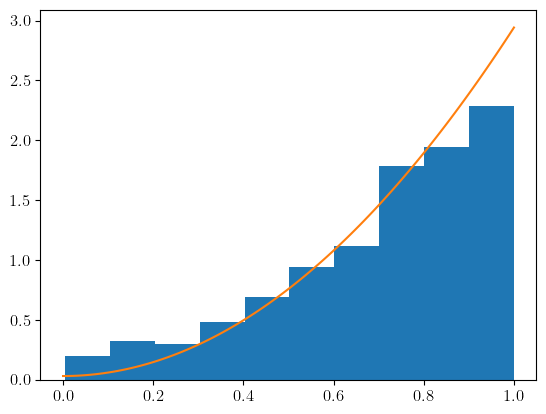

In [ ]:
plt.hist(np.abs(np.cos(events["theta_jn"])), density=True)

u = np.linspace(0, 1, 100)
a = 10
plt.plot(u, (1+ a* u**2)*6/(6+2*a))